In [1]:
import numpy as np
from tensorflow import keras
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import RMSprop

In [2]:
## 2. Load Boston Housing Dataset
## (Available directly in Keras)
(X_train, Y_train), (X_test, Y_test) = keras.datasets.boston_housing.load_data()

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)
print("Train output data shape:", Y_train.shape)
print("Actual Test output data shape:", Y_test.shape)

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (404, 13)
Test data shape: (102, 13)
Train output data shape: (404,)
Actual Test output data shape: (102,)


In [3]:
# 3. Feature Scaling (Important for DNN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

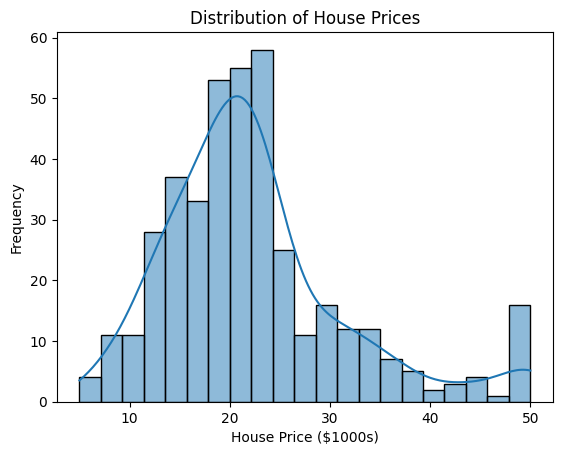

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(Y_train, kde=True)
plt.xlabel("House Price ($1000s)")
plt.ylabel("Frequency")
plt.title("Distribution of House Prices")
plt.show()

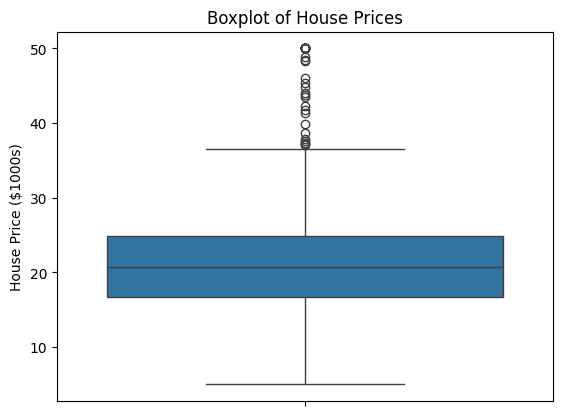

In [5]:
sns.boxplot(y=Y_train)
plt.ylabel("House Price ($1000s)")
plt.title("Boxplot of House Prices")
plt.show()

In [6]:
import pandas as pd

df = pd.DataFrame(X_train)

In [7]:
df.columns = [
    'CRIM','ZN','INDUS','CHAS','NOX','RM','AGE',
    'DIS','RAD','TAX','PTRATIO','B','LSTAT'
]

In [8]:
df['PRICE'] = Y_train

In [9]:
correlation = df.corr()

In [10]:
correlation['PRICE']

,PRICE
CRIM,-0.378498
ZN,0.380299
INDUS,-0.476743
CHAS,0.168661
NOX,-0.438328
RM,0.681483
AGE,-0.364173
DIS,0.253900
RAD,-0.375515
TAX,-0.448737


<Axes: >

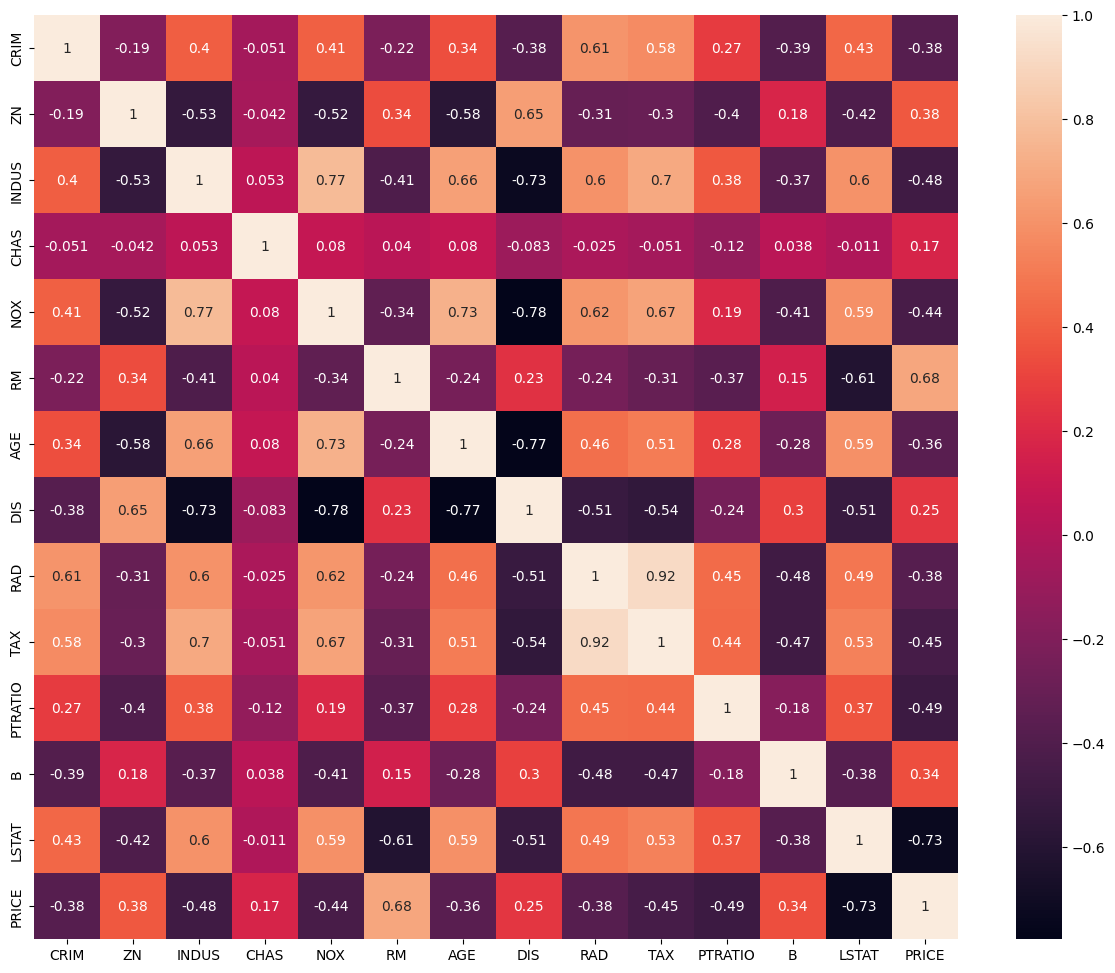

In [30]:
fig,axes = plt.subplots(figsize=(15,12))
sns.heatmap(correlation,square = True,annot = True)

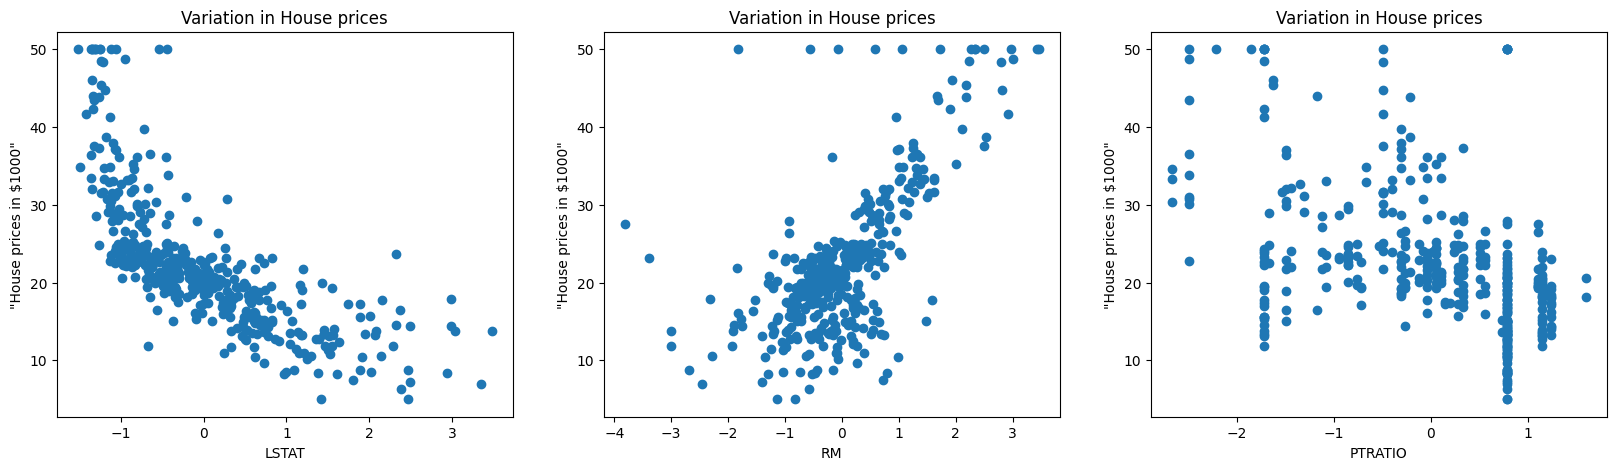

In [31]:
plt.figure(figsize = (20,5))
features = ['LSTAT','RM','PTRATIO']
for i, col in enumerate(features):
    plt.subplot(1, len(features) , i+1)
    x = df[col]
    y = df.PRICE
    plt.scatter(x, y, marker='o')
    plt.title("Variation in House prices")
    plt.xlabel(col)
    plt.ylabel('"House prices in $1000"')

In [32]:
# 4. Build Deep Neural Network Model
model = Sequential()
model.add(Dense(128,activation='relu',input_shape= X_train[0].shape))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(1))

model.summary()

model.compile(loss='mse',optimizer='rmsprop',metrics=['mae'])

history = model.fit(X_train,Y_train,epochs=50,batch_size=1,verbose=1,validation_data=(X_test,Y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,161 (47.50 KB)

 Trainable params: 12,161 (47.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 98.6601 - mae: 6.6023 - val_loss: 21.4952 - val_mae: 3.5275
Epoch 2/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 18.1266 - mae: 2.9398 - val_loss: 22.3383 - val_mae: 3.3566
Epoch 3/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14.6535 - mae: 2.7308 - val_loss: 21.4846 - val_mae: 3.2746
Epoch 4/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12.5378 - mae: 2.4125 - val_loss: 20.7931 - val_mae: 3.1414
Epoch 5/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 11.2447 - mae: 2.4057 - val_loss: 32.9494 - val_mae: 3.9504
Epoch 6/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 11.2934 - mae: 2.4182 - val_loss: 22.1002 - val_mae: 2.9757
Epoch 7/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 10.3793 - mae: 2.3285 - val_loss: 21.9158 - val_mae: 3.1502
Epoch 8/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 10.5974 - mae: 2.2033 - val_loss: 20.7961 - val_mae: 2.9183
Epoch 9/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 

In [33]:
y_pred=model.predict(X_test)
mse_nn, mae_nn = model.evaluate(X_test, Y_test)
print('Mean squared error on test data: ', mse_nn)
print('Mean absolute error on test data: ', mae_nn)
y_pred

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 12.9306 - mae: 2.3940
Mean squared error on test data:  12.93061351776123
Mean absolute error on test data:  2.3939666748046875


array([[ 7.3687224],
       [18.527695 ],
       [20.49654  ],
       [32.929787 ],
       [23.685038 ],
       [23.214977 ],
       [28.377666 ],
       [20.956532 ],
       [18.264374 ],
       [19.619766 ],
       [15.738464 ],
       [15.962776 ],
       [14.86693  ],
       [46.11825  ],
       [20.753872 ],
       [19.731522 ],
       [26.37297  ],
       [18.04597  ],
       [17.726091 ],
       [19.949657 ],
       [10.498711 ],
       [ 9.165964 ],
       [20.647625 ],
       [15.556337 ],
       [18.628714 ],
       [21.62592  ],
       [29.736517 ],
       [27.029985 ],
       [10.114277 ],
       [19.19098  ],
       [19.479527 ],
       [12.537426 ],
       [35.67715  ],
       [24.768826 ],
       [17.568073 ],
       [ 7.3604383],
       [17.043144 ],
       [17.881989 ],
       [17.539713 ],
       [24.970325 ],
       [31.62474  ],
       [27.601114 ],
       [12.487681 ],
       [46.54308  ],
       [28.69629  ],
       [26.835924 ],
       [27.502678 ],
       [19.89

In [34]:
# Make predictions
predictions = model.predict(X_test)
# Display first 5 predictions vs actual prices
for i in range(5):
  print(f"Predicted Price: {predictions[i][0]:.2f}, Actual Price: {Y_test[i]:.2f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Predicted Price: 7.37, Actual Price: 7.20
Predicted Price: 18.53, Actual Price: 18.80
Predicted Price: 20.50, Actual Price: 19.00
Predicted Price: 32.93, Actual Price: 27.00
Predicted Price: 23.69, Actual Price: 22.20
